# SpMV Benchmark Analysis (Native vs SME vs SME+SEV)

This notebook analyzes Sparse Matrix-Vector Multiplication (SpMV) benchmark results across multiple configurations.  
The goal is to quantify performance behavior and overheads of encrypted modes (`SME`, `SME+SEV`) relative to `Native`.

## What this notebook does

- Loads per-iteration and full-run benchmark CSV results from multiple output folders.
- Enriches configurations with derived attributes (for example matrix size in MB, randomness, cache-fit indicators).
- Checks iteration-level stability (warmup behavior, plateau shifts, and variability).
- Cleans run-level metrics using IQR-based outlier handling.
- Aggregates metrics per configuration using medians.
- Builds a baseline comparison against `Native` and computes percentage overheads for:
	- runtime (`SpMV_Time`, `IO_Time`)
	- derived throughput (`SpMV_GFLOPS`)
	- hardware counters (cycles, instructions, cache misses, dTLB misses, IPC)
- Visualizes overhead distributions and breakdowns by key dimensions:
	- matrix size (`MB`)
	- randomness
	- core count
	- VM NUMA policy
	- process NUMA policy
	- L3 cache fit
- Applies statistical analysis (including ANOVA/effect size) to identify dominant factors.
- Extracts and inspects high-impact (worst-overhead) configuration subsets.

## Output

The notebook prints intermediate summaries/tables and saves publication-style figures (PDF) under `images/`.

# 0. Setup

Imports, paths, and shared helpers used throughout the notebook.

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import linregress
from statsmodels.formula.api import ols

sns.set_theme(style="darkgrid", font="DejaVu Serif")  # TODO: replace with thesis font

# ── Colour palette (shared across all plots) ────────────────────────────────
_base = sns.color_palette("deep", 3)
MODE_PALETTE = {
    "Native":  _base[2],
    "SME":     _base[0],
    "SME+SEV": _base[1],
}
MODE_PALETTE_2 = {
    "SME":     "#4c72b0",
    "SME+SEV": "#dd8452",
}


In [2]:
# ── File paths ───────────────────────────────────────────────────────────────
matrix_path  = "/home/mengelsl/MA-bench-framework/matrices/spmv"
results_path = "/home/mengelsl/MA-bench-framework/outputs/spmv"

FOLDERS = {
    "Native":           results_path + "/native/",
    "SME":              results_path + "/sme/",
    "SME+SEV":          results_path + "/sev/",
    "Native_interleave": results_path + "/native_interleave/",
    "SME_interleave":   results_path + "/sme_interleave/",
    "SME+SEV_interleave": results_path + "/sev_interleave/",
}


In [3]:
def get_mb(n, randomness):
    """Return the file size in MiB for the matrix with given N and randomness."""
    r_str  = str(randomness).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(n)}.bin")
    try:
        return round(os.path.getsize(f_path) / (1024 ** 2))
    except FileNotFoundError:
        return None


def iqr_filter(df, cols, k=1.5):
    """Keep only rows within k*IQR of the median for each column in `cols`."""
    mask = pd.Series(True, index=df.index)
    for c in cols:
        q1, q3 = df[c].quantile([0.25, 0.75])
        iqr    = q3 - q1
        mask  &= df[c].between(q1 - k * iqr, q3 + k * iqr)
    return df[mask]


def full_anova(df, target):
    """Run a Type-III ANOVA for `target` on the standard set of predictors.

    Returns a DataFrame sorted by effect size (eta²) descending.
    """
    d       = df.dropna(subset=[target, "MB", "Cores", "Randomness", "Process_NUMA", "VM_NUMA"]).copy()
    formula = f"{target} ~ MB + C(Randomness) + Cores + C(Process_NUMA) + C(VM_NUMA)"
    model   = ols(formula, data=d).fit()
    table   = sm.stats.anova_lm(model, typ=3)   # Type-III SS
    table["eta_sq"] = table["sum_sq"] / table["sum_sq"].sum()
    return table.sort_values("eta_sq", ascending=False)


# 1. Data Validity per Iteration

Load per-iteration CSVs, compute median across parallel runs, 
then assess warmup length and plateau stability for every configuration.

In [4]:
config_cols_iter = ['Mode', 'MB', 'Randomness', 'Cores', 'VM_NUMA', 'Process_NUMA']
iter_list = []

for label, base_path in FOLDERS.items():
    extra_path = os.path.join(base_path, "extra")
    for folder in os.listdir(extra_path):
        csv_p = os.path.join(extra_path, folder, "iter.csv")
        match = re.search(r'(\d-\d)_N(\d+)_c(\d+)_(\w+)', folder)
        if os.path.exists(csv_p) and match:
            it_df = pd.read_csv(csv_p)
            it_df['Mode']        = label.replace("_interleave", "")
            it_df['Randomness']  = float(match.group(1).replace('-', '.'))
            it_df['N']           = int(match.group(2))
            it_df['Cores']       = int(match.group(3))
            it_df['Process_NUMA']= match.group(4)
            it_df['VM_NUMA']     = "interleave" if "interleave" in label else "strict"
            it_df['MB']          = get_mb(it_df['N'].iloc[0], it_df['Randomness'].iloc[0])
            iter_list.append(it_df)

# Takes ~3 minutes
df_iters = (
    pd.concat(iter_list, ignore_index=True)
    .groupby(config_cols_iter + ['Iter'])
    .median()
    .reset_index()
)
print(f"Loaded {len(df_iters) * 15} individual iterations. "
      f"Median computed for {len(df_iters)} data points.")


Loaded 408661650 individual iterations. Median computed for 27244110 data points.


In [5]:
def get_config_stability(group, window_size=15, threshold_pct=5.0, warmup_tol=0.05, stable_window=5):
    """Characterise warmup and plateau-shift behaviour for a single configuration.

    Returns a Series with:
        Warmup_Iters    - first iteration where the signal becomes stable
        Warmup_Pct      - warmup as a fraction of total iterations (%)
        P2P_Shift_Pct   - peak-to-peak shift in the rolling mean post-warmup (%)
        Is_Stable       - True if P2P shift is below `threshold_pct`
        Too_Small       - True if there are too few iterations to assess stability
    """
    times = group['Time'].values
    n     = len(times)

    def _result(warmup_end=None, p2p=None, is_stable=True, too_small=False):
        return pd.Series({
            "Warmup_Iters":  warmup_end,
            "Warmup_Pct":    (warmup_end / n * 100) if warmup_end is not None else np.nan,
            "P2P_Shift_Pct": p2p,
            "Is_Stable":     is_stable,
            "Too_Small":     too_small,
        })

    if n < window_size:
        return _result(too_small=True)

    ref     = np.median(times)
    rel_err = np.abs((times - ref) / ref)

    # Find first stable window
    warmup_end = next(
        (i for i in range(n - stable_window + 1)
         if np.all(rel_err[i:i + stable_window] <= warmup_tol)),
        None
    )
    if warmup_end is None:
        return _result(is_stable=False)

    stable_times = times[warmup_end:]
    if len(stable_times) < window_size:
        return _result(warmup_end=warmup_end, too_small=True)

    rolling    = pd.Series(stable_times).rolling(window=window_size, center=True).mean()
    valid      = rolling.dropna()
    global_med = np.median(stable_times)
    p2p_shift  = (np.percentile(valid, 98) - np.percentile(valid, 2)) / global_med * 100

    return _result(warmup_end=int(warmup_end), p2p=p2p_shift, is_stable=p2p_shift < threshold_pct)


stability_report = (
    df_iters.groupby(config_cols_iter)
    .apply(get_config_stability, include_groups=False)
    .reset_index()
)


### 1.1 Stability summary

In [6]:
print("Too-small configs:", stability_report['Too_Small'].value_counts().to_dict())
print("Stable configs:   ", stability_report['Is_Stable'].value_counts().to_dict())
print()
print(stability_report['Warmup_Pct'].describe().round(2))


Too-small configs: {False: 468, True: 12}
Stable configs:    {True: 471, False: 9}

count    468.00
mean       0.09
std        0.20
min        0.00
25%        0.00
50%        0.01
75%        0.08
max        1.20
Name: Warmup_Pct, dtype: float64


### 1.2 Configs with too few iterations

Verify that these configurations are already effectively stable despite 
the short run length (low slope, CV, and range).

In [7]:
few_iter = df_iters.merge(
    stability_report[stability_report["Too_Small"]], on=config_cols_iter, how='inner'
)

def get_stats(group):
    """Compute slope, CV, and range as % of mean — quick stability proxies."""
    y = group['Time'].values
    x = np.arange(len(y))
    slope_pct = np.polyfit(x, y, 1)[0] / np.mean(y) * 100
    return pd.Series({
        "Slope_Pct": slope_pct,
        "CV_Pct":    np.std(y)  / np.mean(y) * 100,
        "Range_Pct": (np.max(y) - np.min(y)) / np.mean(y) * 100,
    })

few_iter_stats = (
    few_iter.groupby(config_cols_iter)
    .apply(get_stats, include_groups=False)
    .reset_index()
)
print(f"Max slope: {few_iter_stats['Slope_Pct'].abs().max():.4f}%")
print(f"Max CV:    {few_iter_stats['CV_Pct'].abs().max():.4f}%")
print(f"Max range: {few_iter_stats['Range_Pct'].abs().max():.4f}%")
# Verdict: these configs have Is_Stable = True already — nothing to change.


Max slope: 0.0126%
Max CV:    0.0869%
Max range: 0.2012%


### 1.3 Plateau-shift visualisation

Highlight configurations where the rolling mean shifts by more than 5 % 
after warmup (plateau configs), overlaid on stable ones.

In [8]:
def downsample(df, group_cols, n_points=200):
    """Uniformly subsample iterations per config for faster plotting."""
    def _process(grp):
        unique_iters = np.sort(grp['Iter'].unique())
        if len(unique_iters) > n_points:
            idx          = np.linspace(0, len(unique_iters) - 1, n_points).astype(int)
            unique_iters = unique_iters[idx]
        sampled = grp[grp['Iter'].isin(unique_iters)].sort_values('Iter').copy()
        sampled['IterNorm'] = np.linspace(0, 1, len(sampled))
        return sampled
    return df.groupby(group_cols, group_keys=False).apply(_process).reset_index(drop=True)


df_iters_small = downsample(df_iters, group_cols=config_cols_iter, n_points=200)
print(f"Downsampled to {len(df_iters_small)} rows")


Downsampled to 85548 rows


/tmp/ipykernel_577478/352198413.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, group_keys=False).apply(_process).reset_index(drop=True)


/tmp/ipykernel_577478/2488426126.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  comparison_df['Is_Plateau_Config'].fillna(False, inplace=True)
/tmp/ipykernel_577478/2488426126.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comparison_df['Is_Plateau_Config'].fillna(False, inplace=True)


Mode
SME        4
SME+SEV    3
Native     2
Name: count, dtype: int64
MB
70    9
Name: count, dtype: int64
Cores
1    9
Name: count, dtype: int64
Randomness
1.0    9
Name: count, dtype: int64

Average plateau shift: 9.91%


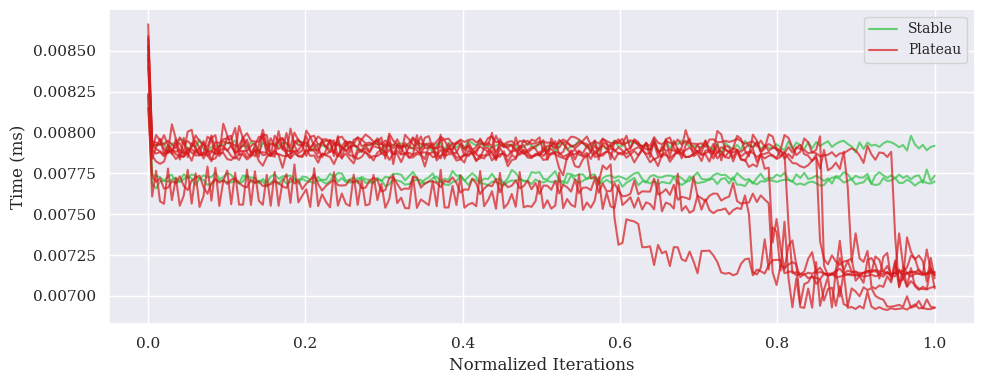

In [9]:
not_straight_large = stability_report[
    (~stability_report['Is_Stable']) & (~stability_report['Too_Small'])
]
print(not_straight_large['Mode'].value_counts())
print(not_straight_large['MB'].value_counts())
print(not_straight_large['Cores'].value_counts())
print(not_straight_large['Randomness'].value_counts())
print(f"\nAverage plateau shift: {not_straight_large['P2P_Shift_Pct'].mean():.2f}%")

# Build comparison slice: MB=70, Cores=1, Randomness=1
comparison_df = df_iters_small[
    (df_iters_small['MB'] == 70) &
    (df_iters_small['Cores'] == 1) &
    (df_iters_small['Randomness'] == 1)
].copy()

shifted_keys   = not_straight_large.merge(comparison_df[config_cols_iter], on=config_cols_iter)[config_cols_iter].drop_duplicates()
comparison_df  = comparison_df.merge(shifted_keys.assign(Is_Plateau_Config=True), on=config_cols_iter, how='left')
comparison_df['Is_Plateau_Config'].fillna(False, inplace=True)
comparison_df['Display_Group']   = np.where(comparison_df['Is_Plateau_Config'], 'Plateau', 'Stable')
comparison_df['Config_Line_ID']  = comparison_df[config_cols_iter].astype(str).agg('-'.join, axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(
    data=comparison_df, x='IterNorm', y='Time',
    hue='Display_Group', units='Config_Line_ID', estimator=None,
    palette={'Plateau': '#d7191c', 'Stable': '#2fc345'},
    alpha=0.7, ax=ax,
)
ax.legend(title=None, frameon=True, fontsize='small')
ax.set_xlabel('Normalized Iterations')
ax.set_ylabel('Time (ms)')
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig('images/SpMV_Stability_Comparison.pdf', bbox_inches='tight')
plt.show()
# Plateau shift occurs between ~60 % and ~90 % of iterations.


### 1.4 Full per-config stability grid

Facet grid of iteration traces grouped by Randomness × VM NUMA × Process NUMA.

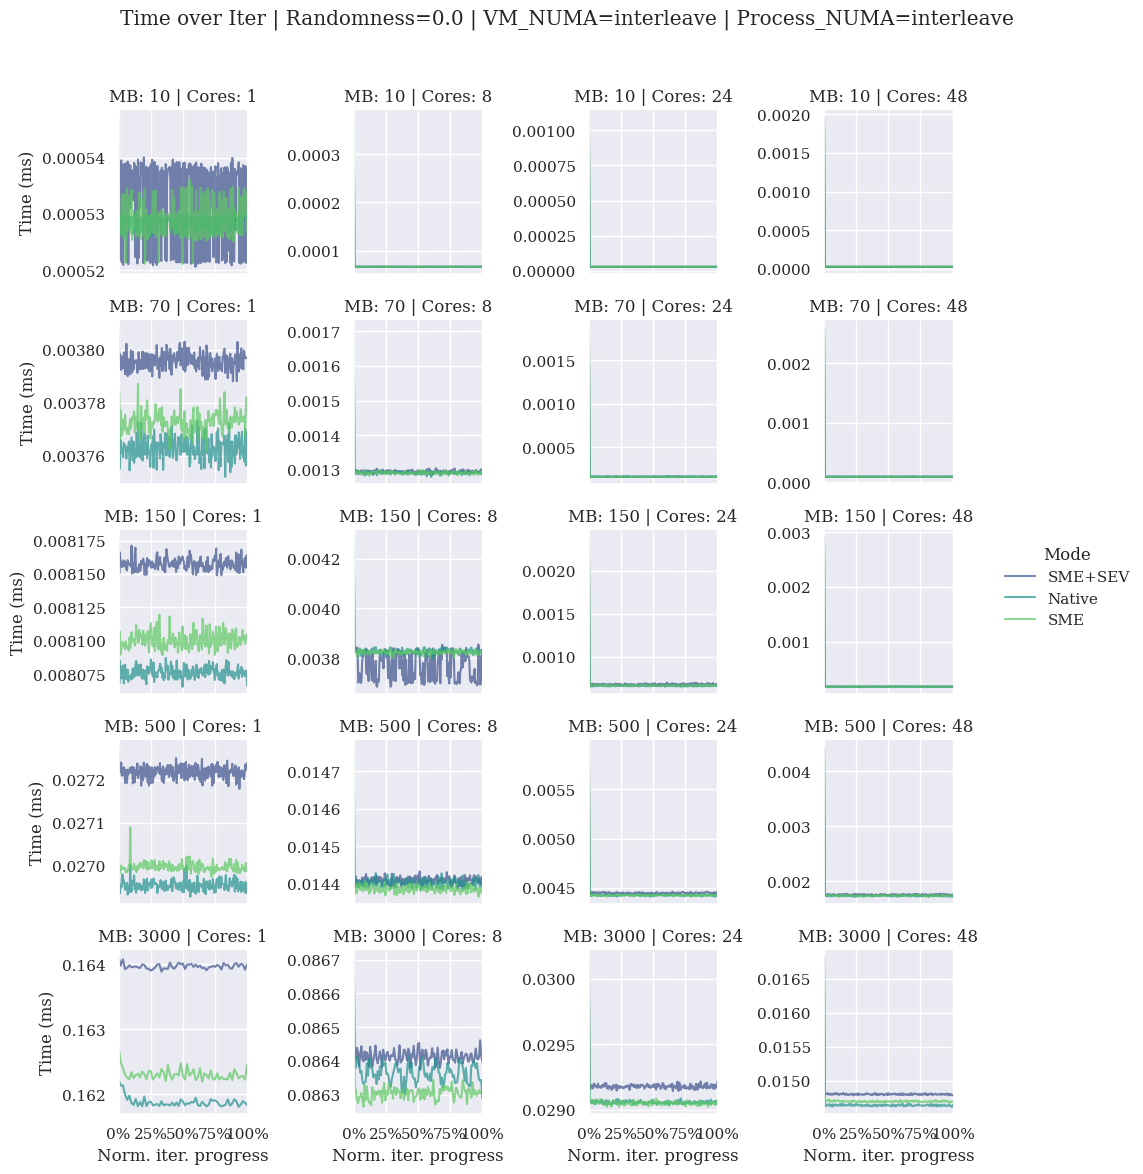

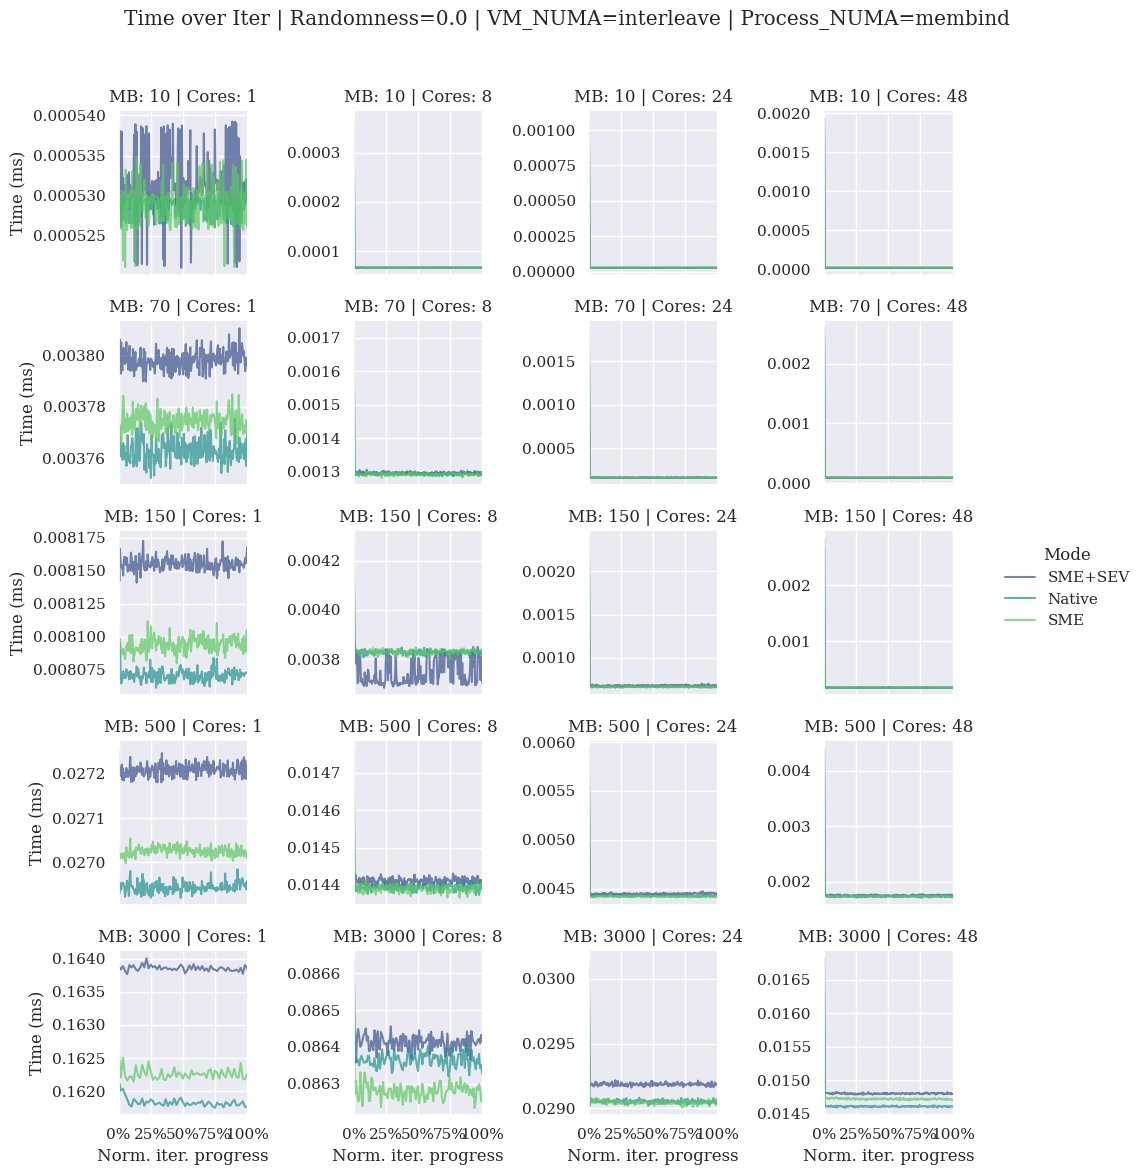

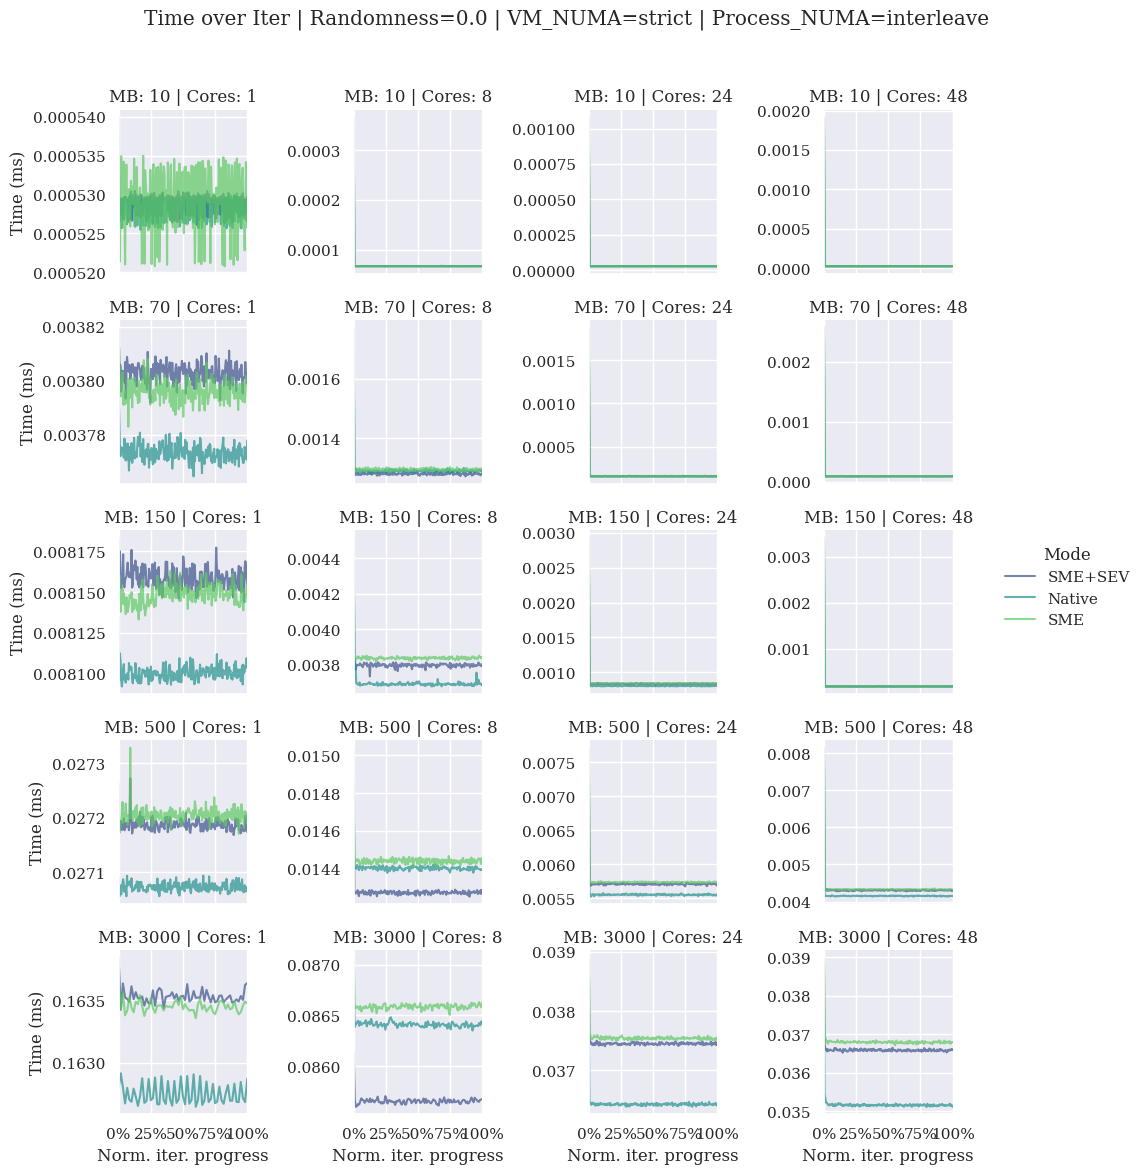

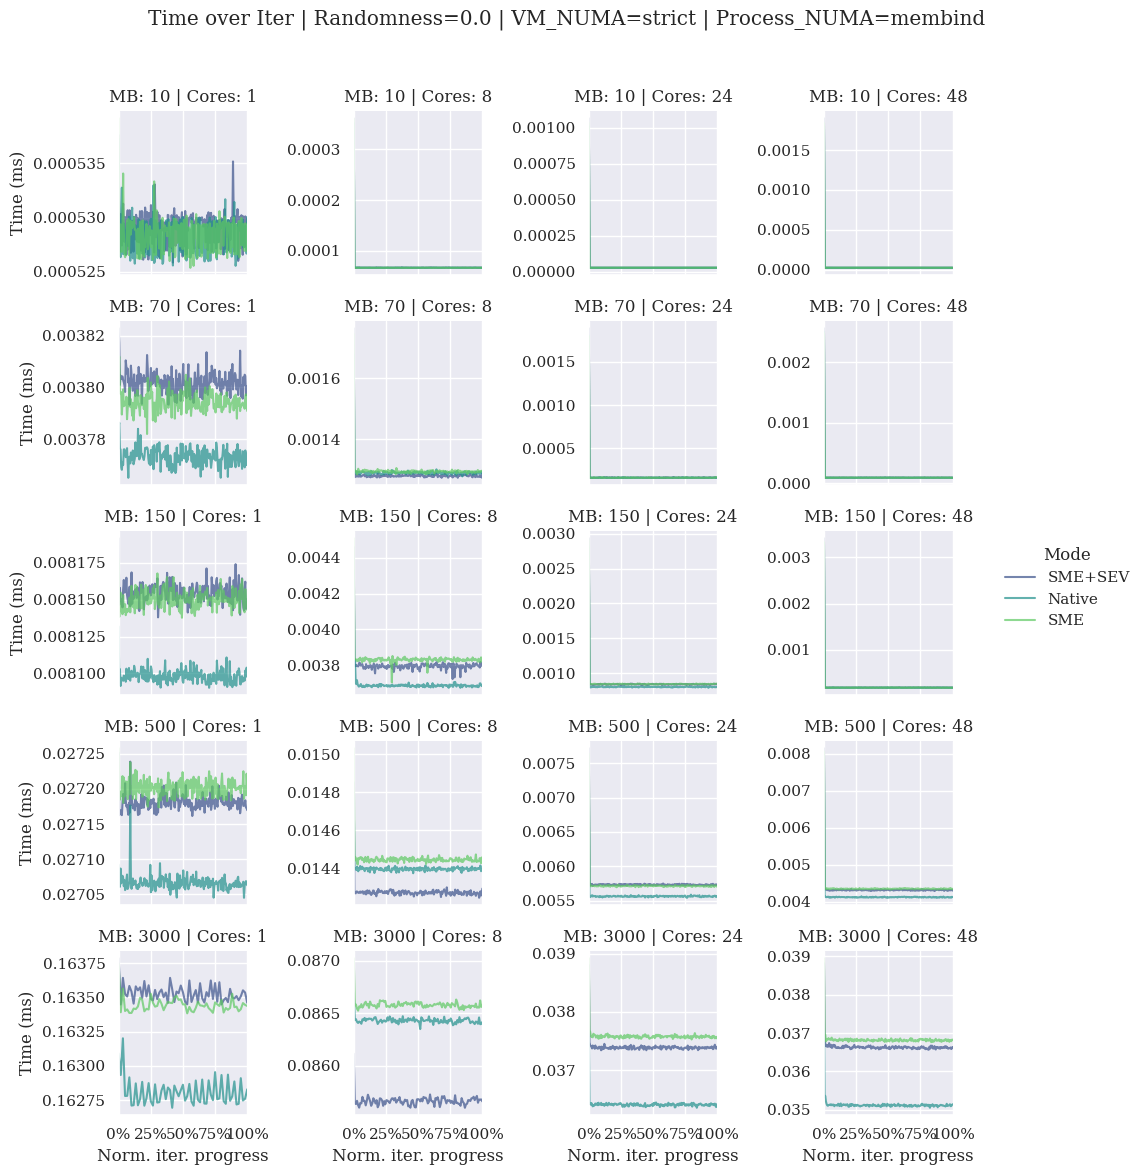

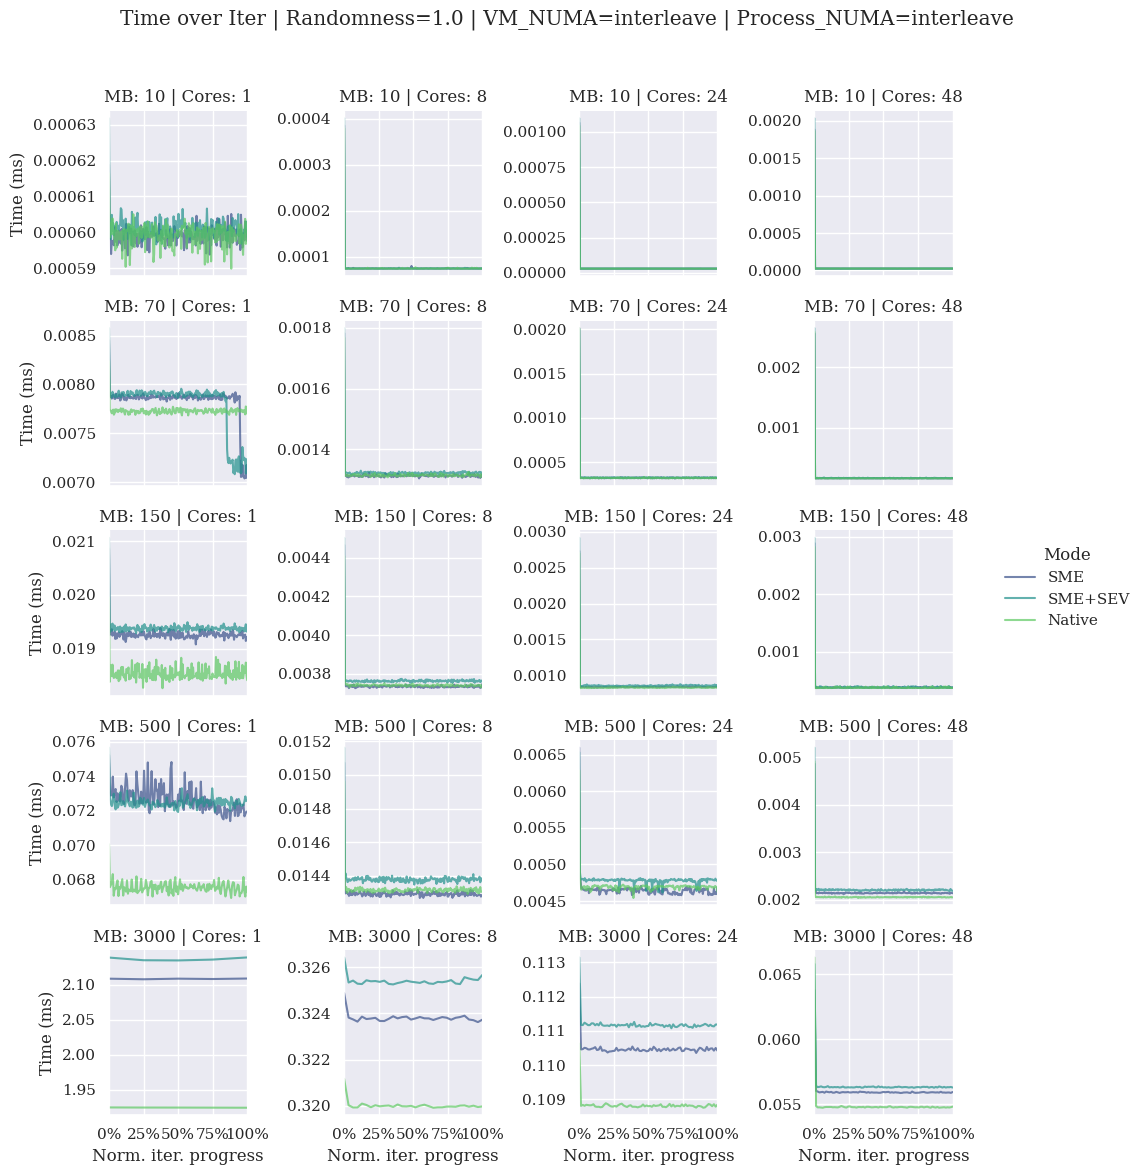

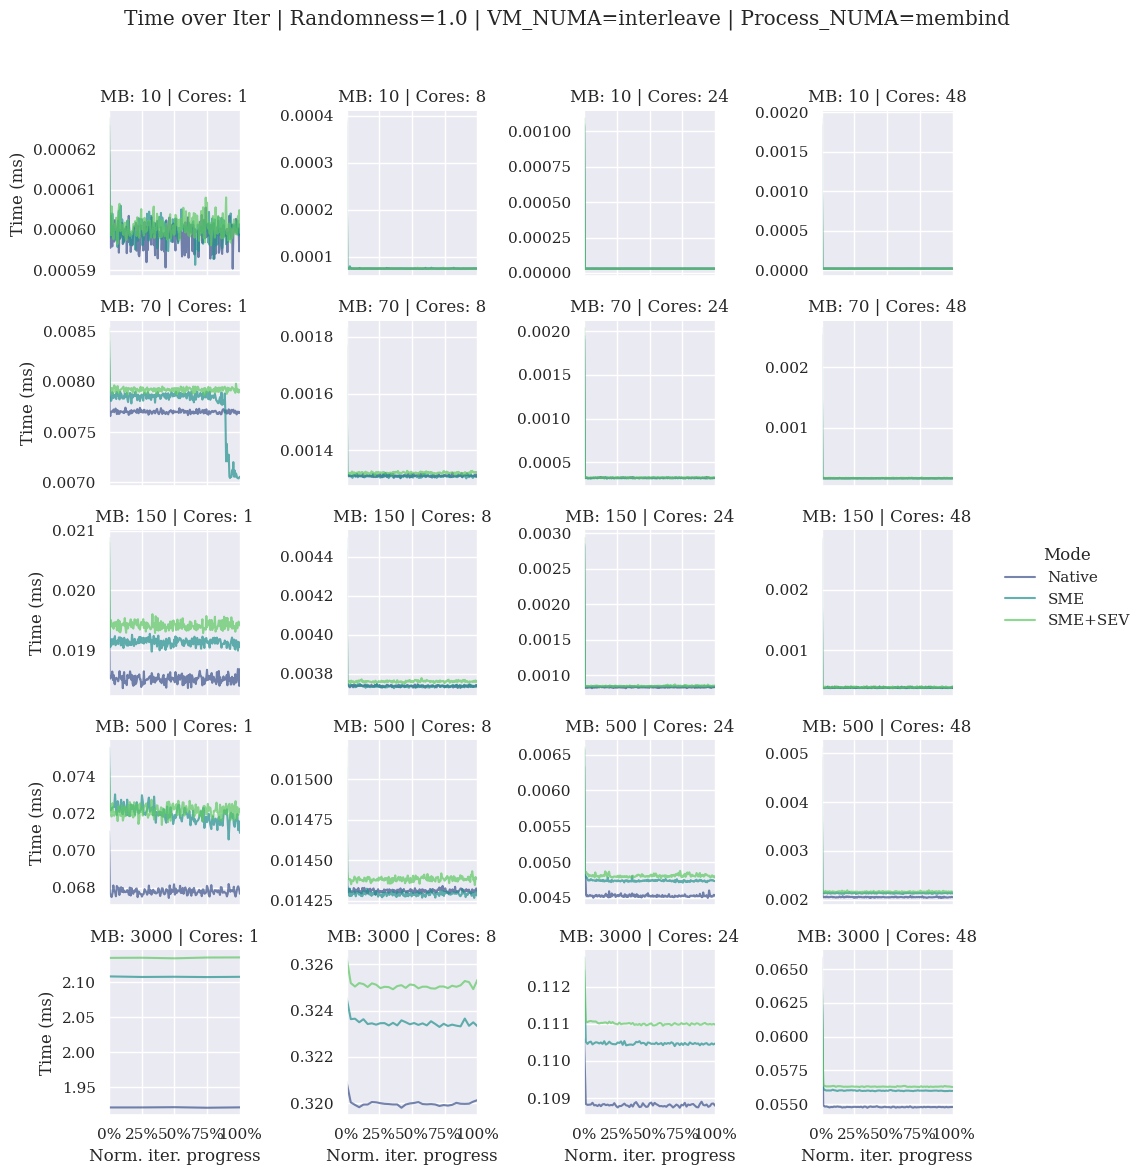

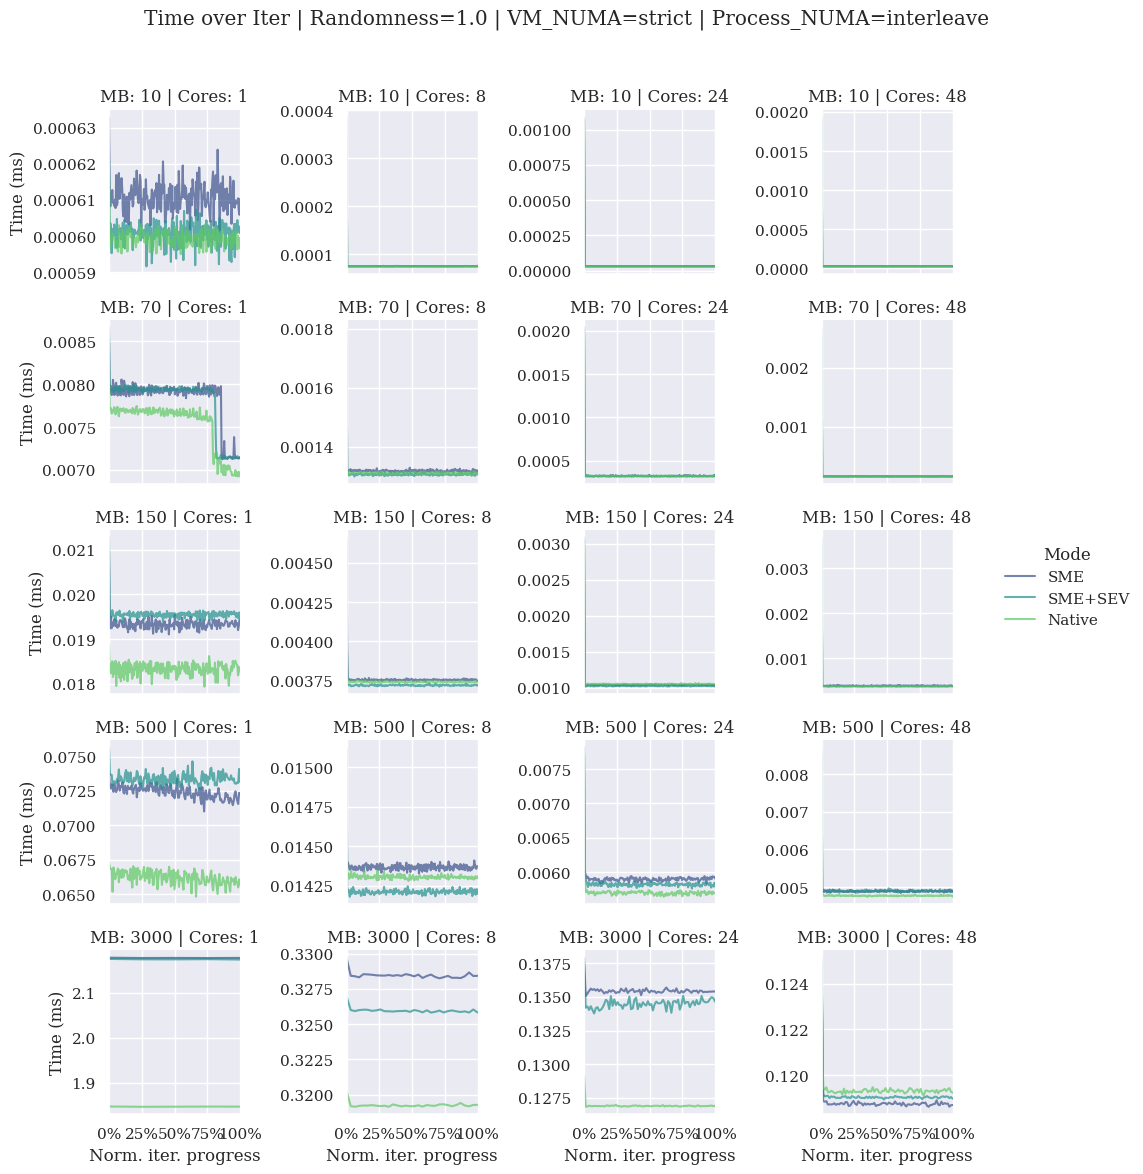

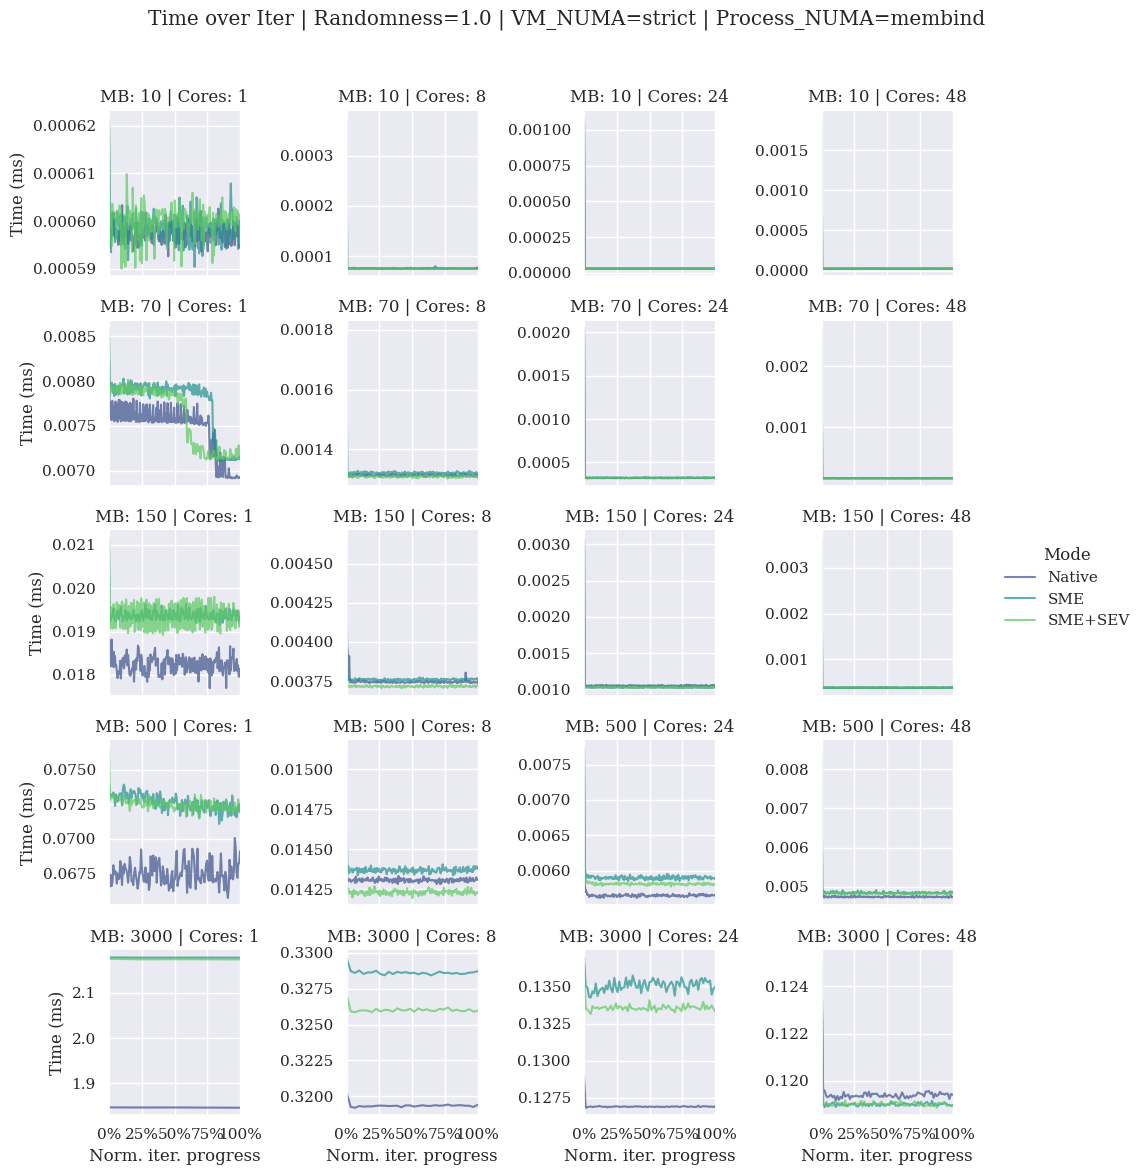

In [10]:
# See visually that most configs are stable

for rnd in sorted(df_iters_small["Randomness"].dropna().unique()):
    for vm in sorted(df_iters_small["VM_NUMA"].dropna().unique()):
        for proc in sorted(df_iters_small["Process_NUMA"].dropna().unique()):
            sub = df_iters_small[
                (df_iters_small["Randomness"] == rnd) &
                (df_iters_small["VM_NUMA"] == vm) &
                (df_iters_small["Process_NUMA"] == proc)
            ].copy()

            if sub.empty:
                continue

            sub = sub.sort_values("IterNorm")

            g = sns.relplot(
                data=sub,
                kind="line",
                x="IterNorm",
                y="Time",
                hue="Mode",
                row="MB",
                col="Cores",
                errorbar=None,
                sort=False,
                palette="viridis",
                facet_kws={"sharey": False, "sharex": True},
                alpha=0.7,
                height=2.3,
                aspect=1.1
            )

            g.set_axis_labels("Norm. iter. progress", "Time (ms)")
            g.set_titles("MB: {row_name} | Cores: {col_name}")
            g.set(xlim=(0, 1), xticks=np.linspace(0, 1, 5))
            g.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
            g.fig.suptitle(
                f"Time over Iter | Randomness={rnd} | VM_NUMA={vm} | Process_NUMA={proc}",
                y=1.02
            )
            g.tight_layout()
            plt.show()

# 2. Aggregated Results Analysis

## 2.1 Data preparation

Load run-level CSVs, apply per-metric IQR outlier removal, then aggregate to 
one median row per configuration.

In [11]:
results_list = []

for label, path in FOLDERS.items():
    f_path = os.path.join(path, 'results.csv')
    if os.path.exists(f_path):
        df_run         = pd.read_csv(f_path)
        df_run['Mode'] = label.split('_interleave')[0]
        df_run['VM_NUMA'] = 'interleave' if 'interleave' in label else 'strict'
        results_list.append(df_run)
        print(f"Loaded {len(df_run):>5} rows  ← {label}")

df_raw = pd.concat(results_list, ignore_index=True)
df_raw.rename(columns={'Process_NUMA_Policy': 'Process_NUMA'}, inplace=True)
print(f"\nTotal rows: {len(df_raw)}")


Loaded  1200 rows  ← Native
Loaded  1200 rows  ← SME
Loaded  1200 rows  ← SME+SEV
Loaded  1200 rows  ← Native_interleave
Loaded  1200 rows  ← SME_interleave
Loaded  1200 rows  ← SME+SEV_interleave

Total rows: 7200


In [12]:
config_cols_raw = ['Mode', 'Matrix', 'Cores', 'Process_NUMA', 'VM_NUMA', 'Iterations']
metric_cols_raw = ['IO_Time', 'SpMV_Time', 'Perf_Cycles', 'Perf_Instructions',
                   'Perf_CacheMisses', 'Perf_dTLBMisses']

config_drop_counts = []

def _iqr_mark_outliers(group):
    """Replace per-metric outliers (IQR method) with NaN within a config group."""
    group      = group.copy()
    group_drops = 0
    for col in metric_cols_raw:
        if col not in group.columns:
            continue
        valid_rows    = group[[col]].dropna()
        filtered_rows = iqr_filter(valid_rows, [col])
        outlier_idx   = valid_rows.index.difference(filtered_rows.index)
        group_drops  += len(outlier_idx)
        group.loc[outlier_idx, col] = np.nan
    config_drop_counts.append(group_drops)
    return group

df_clean = (
    df_raw.groupby(config_cols_raw)
    .apply(_iqr_mark_outliers, include_groups=False)
    .reset_index()
)

total_removed = sum(config_drop_counts)
total_pts     = len(df_raw) * len(metric_cols_raw)
print(f"Total metric data points:  {total_pts}")
print(f"Outlier data points removed: {total_removed} ({total_removed / total_pts * 100:.2f}%)")


Total metric data points:  43200
Outlier data points removed: 2193 (5.08%)


In [13]:
def compute_cv(df, config_cols, metrics):
    """Return mean coefficient of variation per metric across all configs."""
    stats = df.groupby(config_cols)[metrics].agg(['mean', 'std'])
    cv    = stats.xs('std', level=1, axis=1) / stats.xs('mean', level=1, axis=1)
    return cv.mean()


cv_raw   = compute_cv(df_raw,   config_cols_raw, metric_cols_raw)
cv_clean = compute_cv(df_clean, config_cols_raw, metric_cols_raw)

print("Mean CV — raw data:")
print(cv_raw.round(3).to_string())
print("\nMean CV — IQR-cleaned data:")
print(cv_clean.round(3).to_string())


Mean CV — raw data:
IO_Time              0.095
SpMV_Time            0.005
Perf_Cycles          0.005
Perf_Instructions    0.000
Perf_CacheMisses     0.045
Perf_dTLBMisses      0.247

Mean CV — IQR-cleaned data:
IO_Time              0.011
SpMV_Time            0.004
Perf_Cycles          0.004
Perf_Instructions    0.000
Perf_CacheMisses     0.025
Perf_dTLBMisses      0.166


In [ ]:
# Aggregate to one median row per configuration
df = df_clean.groupby(config_cols_raw)[metric_cols_raw].median().reset_index()

# Derived columns
df['N']          = df['Matrix'].str.extract(r'N(\d+)').astype(int)
r                = df['Matrix'].str.extract(r'(\d)-(\d)')
df['Randomness'] = (r[0] + "." + r[1]).astype(float)
df['MB']         = df.apply(lambda row: get_mb(row['N'], row['Randomness']), axis=1).astype('Int64')

K_NNZ = 30  # assumed non-zeros per row
# SpMV_Time is the total time for `Iterations` SpMV calls.
df['SpMV_GFLOPS'] = (2 * K_NNZ * df['N']) / ((df['SpMV_Time'] / df['Iterations']) * 1e9)

L3_SIZE_MB = {1: 32, 8: 32, 24: 96, 48: 192}  # L3 per core-count config
df['L3_fit']   = df['MB'] <= df['Cores'].map(L3_SIZE_MB)
df['Perf_IPC'] = df['Perf_Instructions'] / df['Perf_Cycles']
df.drop(columns=['N', 'Matrix'], inplace=True)

config_cols = ['Mode', 'MB', 'Randomness', 'Cores', 'Process_NUMA', 'VM_NUMA', 'L3_fit']
metric_cols = metric_cols_raw + ['SpMV_GFLOPS', 'Perf_IPC']

df.head()


,Mode,Cores,Process_NUMA,VM_NUMA,Iterations,IO_Time,SpMV_Time,Perf_Cycles,Perf_Instructions,Perf_CacheMisses,Perf_dTLBMisses,Randomness,MB,SpMV_GFLOPS,L3_fit,Perf_IPC
0,Native,1,interleave,interleave,369,0.081600,9.948239,3.613565e+10,1.993093e+11,3298979.0,364995.0,0.0,500,3.205531,False,5.515586
1,Native,1,interleave,strict,369,0.082036,9.993071,3.630054e+10,1.993093e+11,3276049.0,395074.5,0.0,500,3.191150,False,5.490532
2,Native,1,membind,interleave,369,0.081796,9.945920,3.612669e+10,1.993093e+11,3276159.0,345223.0,0.0,500,3.206279,False,5.516955
3,Native,1,membind,strict,369,0.081642,9.991050,3.630536e+10,1.993093e+11,3250803.0,344848.0,0.0,500,3.191796,False,5.489804
4,Native,8,interleave,interleave,713,0.081595,10.267954,2.962630e+11,3.852660e+11,16812143.0,16328.0,0.0,500,6.001026,False,1.300419


In [38]:
# Sanity check: IPC vs GFLOPS correlation
res_gflops = linregress(df['Perf_IPC'] * df['Cores'], df['SpMV_GFLOPS'])
res_time   = linregress(df['Perf_IPC'] * df['Cores'], df['SpMV_Time'])
print(f"IPC x Cores → SpMV_GFLOPS: R² = {res_gflops.rvalue**2:.3f}")
print(f"IPC x Cores → SpMV_Time:   R² = {res_time.rvalue**2:.3f}")


IPC x Cores → SpMV_GFLOPS: R² = 1.000
IPC x Cores → SpMV_Time:   R² = 0.002


In [16]:
# Build overhead DataFrame: percentage difference vs. Native for each metric
merge_cols = [c for c in config_cols if c != 'Mode']

df_native = df[df['Mode'] == 'Native'].copy()
df_other  = df[df['Mode'] != 'Native'].copy()

overhead_df = df_other.merge(df_native, on=merge_cols, suffixes=('', '_native'))

for m in metric_cols:
    native_col        = f"{m}_native"
    overhead_df[f"{m}_pct"] = np.where(
        overhead_df[native_col] != 0,
        (overhead_df[m] - overhead_df[native_col]) / overhead_df[native_col] * 100,
        np.nan
    )


## 2.2 Absolute GFLOPS baseline

Compare raw GFLOPS across modes split by each system dimension.

→ MB:
Mode  Native  SME  SME+SEV
MB                        
10      40.0 39.4     39.4
70      42.8 42.4     42.0
150     36.9 36.6     36.1
500     14.6 14.3     14.2
3000     7.9  7.8      7.8
------------------------------------------------------------
→ Cores:
Mode   Native  SME  SME+SEV
Cores                      
1         2.4  2.3      2.3
8        10.0 10.0     10.0
24       34.9 34.5     34.4
48       66.3 65.5     64.9
------------------------------------------------------------
→ Randomness:
Mode        Native  SME  SME+SEV
Randomness                      
0.0           34.6 34.2     34.0
1.0           22.2 21.9     21.8
------------------------------------------------------------
→ VM NUMA:
Mode        Native  SME  SME+SEV
VM_NUMA                         
strict        27.2 26.6     26.7
interleave    29.7 29.6     29.1
------------------------------------------------------------
→ Process NUMA:
Mode          Native  SME  SME+SEV
Process_NUMA                      
membind  

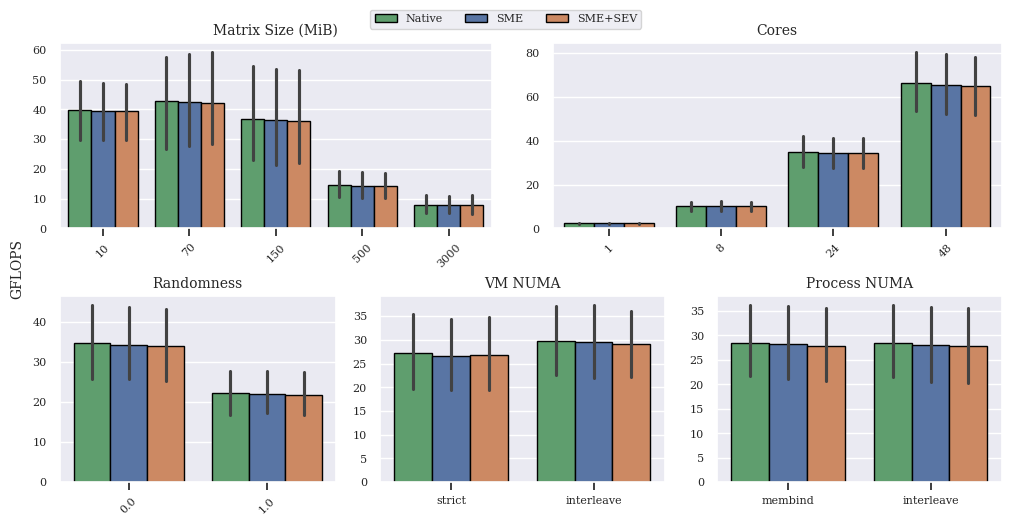

In [39]:
def plot_metric_by_dimensions(
    input_df,
    metric,
    y_axis_name,
    top=False,
    figname=None,
    palette=None,
    legend=True,
    top_metrics=("MB", "Cores"),
    bottom_metrics=("Randomness", "VM_NUMA", "Process_NUMA")
):
    dim_orders = {
        "VM_NUMA": ["strict", "interleave"],
        "Process_NUMA": ["membind", "interleave"],
    }

    has_bottom = bool(bottom_metrics)

    if has_bottom:
        fig = plt.figure(figsize=(10, 5), constrained_layout=True)
        gs = fig.add_gridspec(2, 6, height_ratios=[1, 1])
        axes = {
            top_metrics[0]: fig.add_subplot(gs[0, 0:3]),
            top_metrics[1]: fig.add_subplot(gs[0, 3:6]),
            bottom_metrics[0]: fig.add_subplot(gs[1, 0:2]),
            bottom_metrics[1]: fig.add_subplot(gs[1, 2:4]),
            bottom_metrics[2]: fig.add_subplot(gs[1, 4:6]),
        }
    else:
        fig = plt.figure(figsize=(10, 3), constrained_layout=True)
        gs = fig.add_gridspec(1, 6)
        axes = {
            top_metrics[0]: fig.add_subplot(gs[0, 0:3]),
            top_metrics[1]: fig.add_subplot(gs[0, 3:6]),
        }

    fig.supylabel(y_axis_name, fontsize=10)

    title_map = {
        "MB": "Matrix Size (MiB)",
        "Cores": "Cores",
        "Randomness": "Randomness",
        "VM_NUMA": "VM NUMA",
        "Process_NUMA": "Process NUMA",
    }

    ordered_dims = list(top_metrics) + (list(bottom_metrics) if has_bottom else [])
    legend_handles, legend_labels = None, None

    for a in ordered_dims:
        ax = axes[a]
        sns.barplot(
            data=input_df,
            x=a,
            y=metric,
            hue="Mode",
            order=dim_orders.get(a, None),
            errorbar=("ci", 95),
            edgecolor="black",
            ax=ax,
            palette=palette
        )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        if ax.get_legend() is not None:
            ax.get_legend().remove()

        ax.set_title(title_map.get(a, a.replace("_", " ")), fontsize=10)
        ax.set_ylabel("")
        ax.set_xlabel("")
        rotation = 0 if a in ["VM_NUMA", "Process_NUMA"] else 45
        ax.tick_params(axis="x", rotation=rotation, labelsize=8)
        ax.tick_params(axis="y", labelsize=8)

        if top:
            ax.xaxis.set_ticks_position("top")
            ax.xaxis.set_label_position("top")
        else:
            ax.xaxis.set_ticks_position("bottom")
            ax.xaxis.set_label_position("bottom")

    if legend and legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            ncol=3,
            bbox_to_anchor=(0.5, 1.03),
            fontsize=8
        )

    if figname:
        fig.savefig(f"images/{figname}", bbox_inches="tight")

    for dim in ordered_dims:
        print(f"→ {dim.replace('_', ' ')}:")
        summary = (
            input_df.groupby([dim, "Mode"])[metric]
            .mean()
            .round(2)
            .reset_index()
        )
        summary_pivot = summary.pivot(index=dim, columns="Mode", values=metric)
        if dim in dim_orders:
            summary_pivot = summary_pivot.reindex(dim_orders[dim])

        print(summary_pivot.to_string(float_format="{:.1f}".format))
        print("-" * 60)


plot_metric_by_dimensions(
    df, 'SpMV_GFLOPS', 'GFLOPS',
    top=False, figname='absolute_gflops_per_dim.pdf',
    palette=MODE_PALETTE, legend=True,
)

### Process NUMA policy impact

Assess whether `interleave` vs `membind` makes a meaningful difference.

In [19]:
df.groupby(["Process_NUMA"])["SpMV_GFLOPS"].describe()

,count,mean,std,min,25%,50%,75%,max
Process_NUMA,,,,,,,,
interleave,240.0,28.121667,34.818440,0.238114,3.242854,11.626917,39.090080,145.151422
membind,240.0,28.147906,34.834007,0.238104,3.242850,11.614127,39.194176,145.341399


In [20]:
# Average GFLOPS deviation between Process_NUMA policies (interleave vs membind)
pair_cols = ['Mode', 'MB', 'Randomness', 'Cores', 'VM_NUMA']

proc_cmp = (
    df.pivot_table(index=pair_cols, columns='Process_NUMA', values='SpMV_GFLOPS')
    .dropna(subset=['membind', 'interleave'])
    .reset_index()
)
proc_cmp['Deviation_pct']     = (proc_cmp['interleave'] - proc_cmp['membind']) / proc_cmp['membind'] * 100
proc_cmp['Deviation_pct_abs'] = proc_cmp['Deviation_pct'].abs()

print("Overall deviation stats:")
print(proc_cmp[['Deviation_pct_abs']].agg(['mean', 'std']).round(3))
print("\nConfigs with > 2 % deviation:")
print(proc_cmp[proc_cmp['Deviation_pct_abs'] > 2])


Overall deviation stats:
Process_NUMA  Deviation_pct_abs
mean                      0.313
std                       0.612

Configs with > 2 % deviation:
Process_NUMA     Mode   MB  Randomness  Cores     VM_NUMA  interleave  \
57             Native  500         1.0      1      strict    1.313443   
60             Native  500         1.0     24  interleave   18.455402   
86                SME   10         0.0     48  interleave   74.651553   
94                SME   10         1.0     48  interleave   70.896068   
103               SME   70         0.0     48      strict  128.178506   
127               SME  150         1.0     48      strict   65.612935   
136               SME  500         1.0      1  interleave    1.174146   
185           SME+SEV   70         1.0      1      strict    1.550509   

Process_NUMA     membind  Deviation_pct  Deviation_pct_abs  
57              1.285691       2.158532           2.158532  
60             19.116838      -3.459966           3.459966  
86     

### VM NUMA boost: interleave vs strict

Heatmap of GFLOPS boost (%) when switching from `strict` to `interleave` VM NUMA, 
broken down by Matrix Size × Cores for each mode.

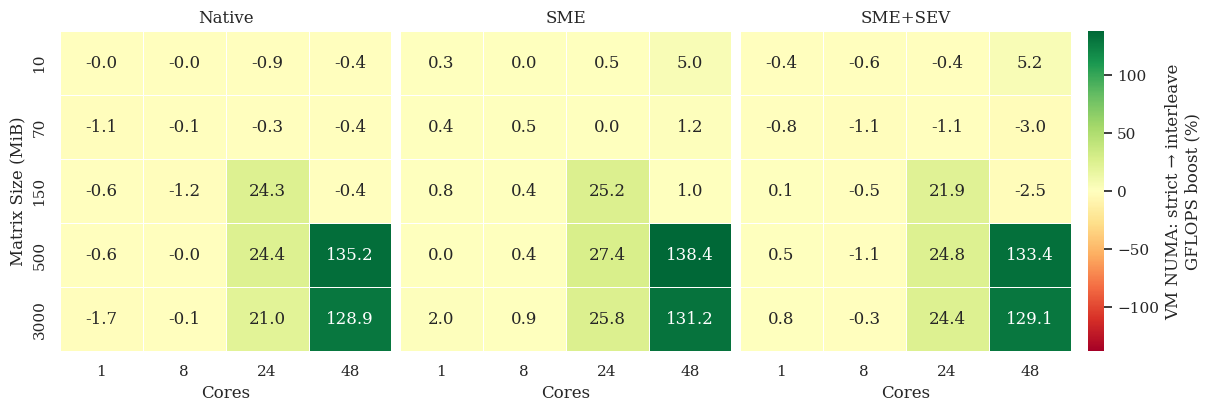

In [21]:
# VM_NUMA boost: interleave vs strict
heat_df = (
	df.pivot_table(
		index=["Mode", "MB", "Cores", "Randomness", "Process_NUMA"],
		columns="VM_NUMA",
		values="SpMV_GFLOPS",
		aggfunc="mean"
	)
	.dropna(subset=["interleave", "strict"])
	.reset_index()
)

heat_df["Boost_pct"] = (heat_df["interleave"] - heat_df["strict"]) / heat_df["strict"] * 100

# Per-mode cell values (MB, Cores, Mode)
mode_cell = (
	heat_df.groupby(["MB", "Cores", "Mode"], as_index=False)["Boost_pct"]
	.mean()
)

mode_order = ["Native", "SME", "SME+SEV"]
modes = [m for m in mode_order if m in mode_cell["Mode"].unique()]

vabs = mode_cell["Boost_pct"].abs().max()
fig, axes = plt.subplots(1, len(modes), figsize=(12, 4), constrained_layout=True, sharey=True)

if len(modes) == 1:
	axes = [axes]

for i, mode in enumerate(modes):
	p_mode = (
		mode_cell[mode_cell["Mode"] == mode]
		.pivot(index="MB", columns="Cores", values="Boost_pct")
		.sort_index()
	)
	p_mode = p_mode.reindex(sorted(p_mode.columns), axis=1)

	sns.heatmap(
		p_mode,
		ax=axes[i],
		cmap="RdYlGn",
		center=0,
		vmin=-vabs,
		vmax=vabs,
		annot=True,
		fmt=".1f",
		linewidths=0.4,
		linecolor="white",
		cbar=(i == len(modes) - 1),
		cbar_kws={"label": "VM NUMA: strict → interleave\nGFLOPS boost (%)"} if i == len(modes) - 1 else None
	)

	axes[i].set_title(mode)
	axes[i].set_xlabel("Cores")
	if i == 0:
		axes[i].set_ylabel("Matrix Size (MiB)")
	else:
		axes[i].set_ylabel("")
		axes[i].tick_params(axis="y", left=False, labelleft=False)

fig.savefig("images/vm_numa_boost_heatmap_by_mode.pdf", bbox_inches="tight")
plt.show()

## 2.3 GFLOPS overhead overview

Distribution of GFLOPS overhead (relative to Native) across all configurations.

In [ ]:
print(overhead_df.groupby('Mode')['SpMV_GFLOPS_pct'].aggregate(['mean', 'median']).round(2))

         mean  median
Mode                 
SME     -1.61   -0.44
SME+SEV -1.88   -1.08


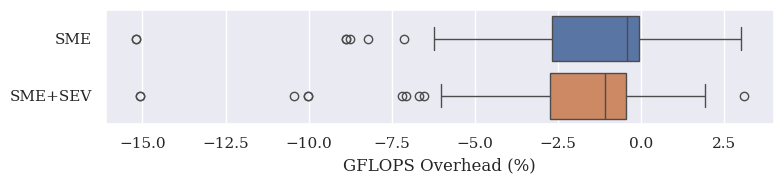

In [ ]:
fig, ax = plt.subplots(figsize=(8, 2))
sns.boxplot(data=overhead_df, x='SpMV_GFLOPS_pct', y='Mode', hue='Mode', ax=ax)
ax.set_xlabel('GFLOPS Overhead (%)')
ax.set_ylabel('')
fig.tight_layout()
fig.savefig('images/GFLOPS_Overhead_Distribution.pdf', bbox_inches='tight')
plt.show()

In [ ]:
for mode, col in [('SME', 'SME'), ('SME+SEV', 'SME+SEV')]:
    n_low   = ((overhead_df['Mode'] == mode) & (overhead_df['SpMV_GFLOPS_pct'] > -1)).sum()
    n_total = (overhead_df['Mode'] == mode).sum()
    print(f"{mode} with overhead > -1 %: {n_low}/{n_total} = {n_low/n_total:.2%}")

n_gt1 = (overhead_df['SpMV_GFLOPS_pct'] > 1).sum()
n_gt0 = (overhead_df['SpMV_GFLOPS_pct'] > 0).sum()
n_tot = overhead_df['SpMV_GFLOPS_pct'].count()
print(f"\nEncrypted outperforms Native by > 1 %: {n_gt1}/{n_tot} = {n_gt1/n_tot:.2%}")
print(f"Encrypted outperforms Native by > 0 %: {n_gt0}/{n_tot} = {n_gt0/n_tot:.2%}")

SME with overhead > -1 %: 99/160 = 61.88%
SME+SEV with overhead > -1 %: 77/160 = 48.12%

Encrypted outperforms Native by > 1 %: 9/320 = 2.81%
Encrypted outperforms Native by > 0 %: 55/320 = 17.19%


## 2.4 ANOVA — dominant factors

Type-III ANOVA with eta² effect sizes to identify which system parameters 
most strongly drive GFLOPS overhead.

In [ ]:
def run_anova(df, targets):
    """Run full_anova for each target × mode combination and print sorted results."""
    df = df.copy()
    for col in ('MB', 'Cores', 'Randomness'):
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('float64')

    print(f"Rows: {len(df)}")
    results = {}
    for target in targets:
        for mode in ('SME', 'SME+SEV'):
            table = full_anova(df[df['Mode'] == mode].copy(), target)
            results[(target, mode)] = table
            print(f"\n{'='*60}\nTarget: {target}  |  Mode: {mode}\n{'='*60}")
            print(table)
    return results


anova_results = run_anova(overhead_df, targets=['SpMV_GFLOPS_pct'])

Rows: 320

Target: SpMV_GFLOPS_pct  |  Mode: SME
                     sum_sq     df          F    PR(>F)    eta_sq
Residual         877.132548  154.0        NaN       NaN  0.793543
C(VM_NUMA)        86.968057    1.0  15.269164  0.000139  0.078680
MB                79.699366    1.0  13.992985  0.000258  0.072104
C(Randomness)     57.931618    1.0  10.171176  0.001728  0.052411
Cores              3.140076    1.0   0.551310  0.458914  0.002841
C(Process_NUMA)    0.451741    1.0   0.079313  0.778608  0.000409
Intercept          0.014394    1.0   0.002527  0.959971  0.000013

Target: SpMV_GFLOPS_pct  |  Mode: SME+SEV
                     sum_sq     df          F    PR(>F)    eta_sq
Residual         987.123490  154.0        NaN       NaN  0.871063
C(Randomness)     73.549301    1.0  11.474342  0.000896  0.064902
MB                60.015953    1.0   9.363020  0.002612  0.052960
Intercept         10.373544    1.0   1.618365  0.205238  0.009154
Cores              1.501463    1.0   0.234242  0.6

## 2.5 System parameter effects

Mean GFLOPS overhead broken down by core count and access pattern randomness.

Mean GFLOPS overhead (%) per Randomness / Cores / Mode:
 Randomness  Cores    Mode  SpMV_GFLOPS_pct
        0.0      1     SME             -0.3
        0.0      1 SME+SEV             -0.7
        0.0      8     SME             -0.4
        0.0      8 SME+SEV              0.1
        0.0     24     SME             -1.4
        0.0     24 SME+SEV             -1.8
        0.0     48     SME             -1.9
        0.0     48 SME+SEV             -2.4
        1.0      1     SME             -5.4
        1.0      1 SME+SEV             -5.6
        1.0      8     SME             -0.5
        1.0      8 SME+SEV             -0.5
        1.0     24     SME             -1.7
        1.0     24 SME+SEV             -2.1
        1.0     48     SME             -1.3
        1.0     48 SME+SEV             -2.1


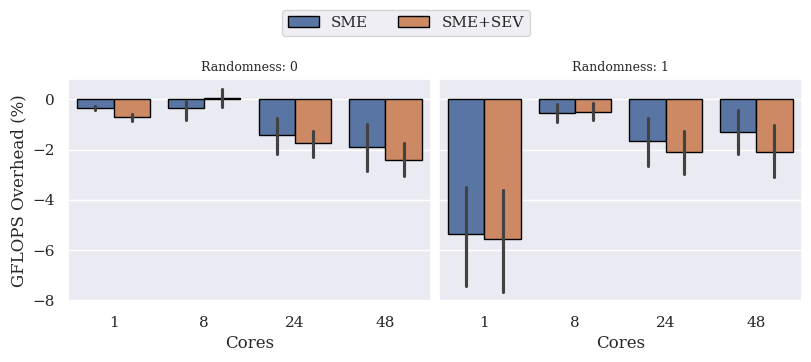

In [ ]:
plot_df = overhead_df.copy()
plot_df['Cores']      = pd.to_numeric(plot_df['Cores'],      errors='coerce').astype('Int64').astype(int)
plot_df['Randomness'] = pd.to_numeric(plot_df['Randomness'], errors='coerce')
plot_df = plot_df.dropna(subset=['Cores', 'Randomness', 'Mode', 'SpMV_GFLOPS_pct'])

core_order = sorted(plot_df['Cores'].unique())
rnd_order  = sorted(plot_df['Randomness'].unique())

display_values = (
    plot_df.groupby(['Randomness', 'Cores', 'Mode'], as_index=False)['SpMV_GFLOPS_pct']
    .mean().round(1)
    .sort_values(['Randomness', 'Cores', 'Mode'])
)
print('Mean GFLOPS overhead (%) per Randomness / Cores / Mode:')
print(display_values.to_string(index=False))

fig, axes = plt.subplots(1, len(rnd_order), figsize=(4 * len(rnd_order), 3),
                          constrained_layout=True, sharey=True)
if len(rnd_order) == 1:
    axes = [axes]

for i, rnd in enumerate(rnd_order):
    ax  = axes[i]
    sub = plot_df[plot_df['Randomness'] == rnd]
    sns.barplot(data=sub, x='Cores', y='SpMV_GFLOPS_pct', hue='Mode',
                order=core_order, hue_order=['SME', 'SME+SEV'],
                palette=MODE_PALETTE_2, errorbar=('ci', 95),
                edgecolor='black', ax=ax)
    ax.set_title(f'Randomness: {int(rnd)}', fontsize=9)
    ax.set_xlabel('Cores')
    ax.set_ylabel('GFLOPS Overhead (%)' if i == 0 else '')
    if ax.get_legend():
        ax.get_legend().remove()
    if i > 0:
        ax.tick_params(labelleft=False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.18))
fig.savefig('images/gflops_cores_randomness.pdf', bbox_inches='tight')
plt.show()

## 2.6 Memory hierarchy effects

Impact of L3 cache fit on GFLOPS overhead.

L3_fit  Mode   
False   SME       -2.07
        SME+SEV   -2.19
True    SME       -0.77
        SME+SEV   -1.30
Name: SpMV_GFLOPS_pct, dtype: float64

L3-fit configs: 168 / 480


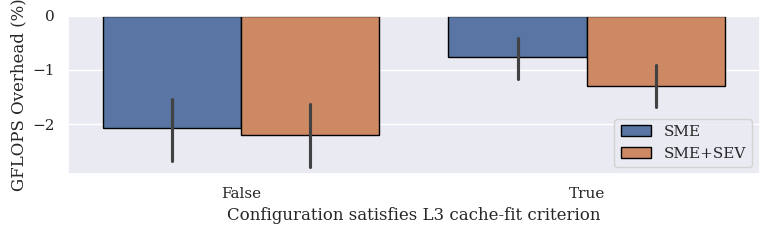

In [ ]:
fig, ax = plt.subplots(figsize=(8, 2.5))
sns.barplot(overhead_df, x='L3_fit', y='SpMV_GFLOPS_pct', hue='Mode',
            edgecolor='black', ax=ax)
ax.legend(title=None)
ax.set_xlabel('Configuration satisfies L3 cache-fit criterion')
ax.set_ylabel('GFLOPS Overhead (%)')
fig.tight_layout()
fig.savefig('images/overhead_by_L3_fit_SpMV_GFLOPS_pct.pdf', bbox_inches='tight')
print(overhead_df.groupby(['L3_fit', 'Mode'])['SpMV_GFLOPS_pct'].mean().round(2))
print(f"\nL3-fit configs: {df['L3_fit'].sum()} / {len(df)}")

## 2.7 Input matrix effects

How matrix size and access-pattern randomness drive GFLOPS overhead, 
and whether that impact is modulated by L3 fit or VM NUMA policy.

→ MB:
Mode  SME  SME+SEV
MB                
10   -0.9     -1.0
70   -0.7     -1.2
150  -1.3     -1.9
500  -2.3     -2.4
3000 -2.9     -3.0
------------------------------------------------------------
→ Randomness:
Mode        SME  SME+SEV
Randomness              
0.0        -1.0     -1.2
1.0        -2.2     -2.6
------------------------------------------------------------


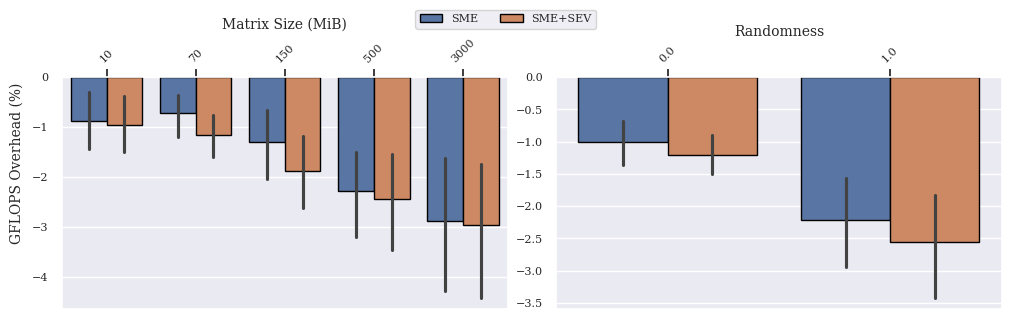

In [ ]:
plot_metric_by_dimensions(
    overhead_df, 'SpMV_GFLOPS_pct', 'GFLOPS Overhead (%)',
    top=True, figname='overhead_by_mb_randomness.pdf',
    top_metrics=['MB', 'Randomness'], bottom_metrics=None,
)


Displayed bar values for L3_fit:
 L3_fit    Mode  Impact
  False     SME    -2.0
  False SME+SEV    -2.2
   True     SME     0.2
   True SME+SEV     0.1

Displayed bar values for VM_NUMA:
   VM_NUMA    Mode  Impact
    strict     SME    -1.0
    strict SME+SEV    -1.1
interleave     SME    -1.4
interleave SME+SEV    -1.7


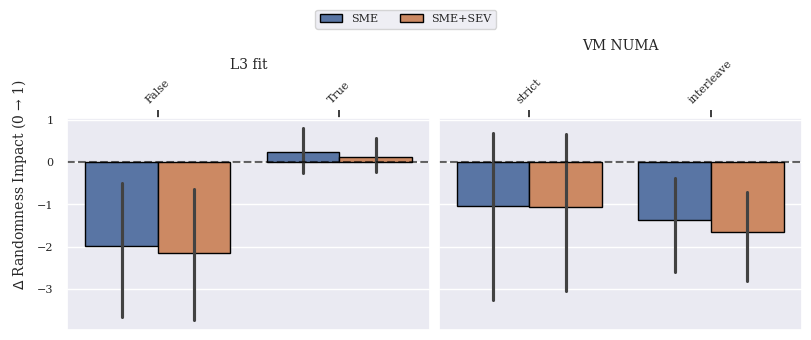

In [29]:
#matrix pattern impact
# Global configuration: (Baseline/Low State, Stressed/High State)
# Order matters: Impact = High - Low
DIM_CONFIG = {
    'Randomness': (0, 1),
    'VM_NUMA': ('strict', 'interleave'),
    'L3_fit': (True, False),
}

def get_impact_df(df, target_dim):
    """
    Calculates pairwise delta for target_dim using DIM_CONFIG.
    For MB/Cores, it defaults to (min, max).
    """
    all_dims = ['Mode', 'MB', 'Cores', 'VM_NUMA', 'Randomness', 'L3_fit']
    index_cols = [c for c in all_dims if c != target_dim]
    
    # Get comparison values
    if target_dim in DIM_CONFIG:
        low_val, high_val = DIM_CONFIG[target_dim]
    else:
        low_val, high_val = df[target_dim].min(), df[target_dim].max()
    
    # Pivot and calculate Delta
    pivot = df.pivot_table(
        index=index_cols, 
        columns=target_dim, 
        values='SpMV_GFLOPS_pct'
    ).reset_index()
    
    # Impact = 'Stressed' minus 'Baseline'
    pivot['Impact'] = pivot[high_val] - pivot[low_val]
    
    # Store metadata for the plotter to use in titles
    pivot.attrs['comparison'] = f"{low_val} → {high_val}"
    pivot.attrs['target'] = target_dim
    return pivot

def plot_impact_comparison(impact_df, compare_features, print_bar_values=True):
    """
    Plots the impact with automated, descriptive titles.
    Also prints the displayed bar values (mean Impact per x/hue).
    """
    target = impact_df.attrs.get('target', 'Dimension')
    comp_str = impact_df.attrs.get('comparison', '')

    # Explicit plotting order for categorical dimensions
    order_map = {
        "VM_NUMA": ["strict", "interleave"],
    }

    fig, axes = plt.subplots(1, len(compare_features), figsize=(8, 3), constrained_layout=True, sharey=True)
    if len(compare_features) == 1:
        axes = [axes]

    fig.supylabel(f"$\\Delta$ {target} Impact ({comp_str})", fontsize=10)

    for i, feat in enumerate(compare_features):
        ax = axes[i]
        x_order = [v for v in order_map.get(feat, []) if v in impact_df[feat].dropna().unique()] or None

        if print_bar_values:
            bar_vals = (
                impact_df.groupby([feat, "Mode"], as_index=False)["Impact"]
                .mean()
                .round(1)
            )
            if x_order is not None:
                bar_vals[feat] = pd.Categorical(bar_vals[feat], categories=x_order, ordered=True)
            bar_vals = bar_vals.sort_values([feat, "Mode"])

            print(f"\nDisplayed bar values for {feat}:")
            print(bar_vals.to_string(index=False))

        sns.barplot(
            data=impact_df,
            x=feat,
            y="Impact",
            hue="Mode",
            order=x_order,
            edgecolor="black",
            ax=ax,
        )

        ax.axhline(0, linestyle="--", color="black", alpha=0.6)
        ax.set_title(feat.replace("_", " "), fontsize=10)
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45, labelsize=8)
        ax.tick_params(axis="y", labelsize=8)
        ax.xaxis.set_ticks_position("top")
        ax.xaxis.set_label_position("top")
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=8)

    fig.savefig("images/randomness_impact.pdf", bbox_inches="tight")
    plt.show()

rand_df = get_impact_df(overhead_df, 'Randomness')
plot_impact_comparison(rand_df, ["L3_fit", "VM_NUMA"])


## 2.8 Hardware counter analysis

Examine instruction count, cycle count, cache misses, and dTLB misses 
relative to Native.

### Instructions & Cycles

In [30]:
plot_df = overhead_df.melt(
    id_vars=['Mode'],
    value_vars=['Perf_Instructions_pct', 'Perf_Cycles_pct'],
    var_name='Metric', value_name='Overhead_pct',
)
summary = (
    plot_df.groupby(['Metric', 'Mode'])['Overhead_pct']
    .agg(['mean', 'std'])
    .round(1)
    .reset_index()
)
print(summary.to_string())
print()
print(overhead_df.groupby('Mode')[['Perf_Instructions_pct', 'Perf_Cycles_pct']].describe().round(2))


                  Metric     Mode  mean  std
0        Perf_Cycles_pct      SME   1.8  2.9
1        Perf_Cycles_pct  SME+SEV   1.8  3.0
2  Perf_Instructions_pct      SME  -0.1  0.3
3  Perf_Instructions_pct  SME+SEV  -0.1  0.3

        Perf_Instructions_pct                                          \
                        count  mean   std   min  25%  50%   75%   max   
Mode                                                                    
SME                     160.0 -0.07  0.29 -1.44 -0.0  0.0  0.00  0.15   
SME+SEV                 160.0 -0.06  0.29 -1.42 -0.0  0.0  0.01  0.14   

        Perf_Cycles_pct                                             
                  count  mean   std   min   25%   50%   75%    max  
Mode                                                                
SME               160.0  1.76  2.95 -2.94  0.08  0.47  2.53  17.92  
SME+SEV           160.0  1.83  2.98 -3.33  0.22  0.85  2.38  17.75  


### Cache misses

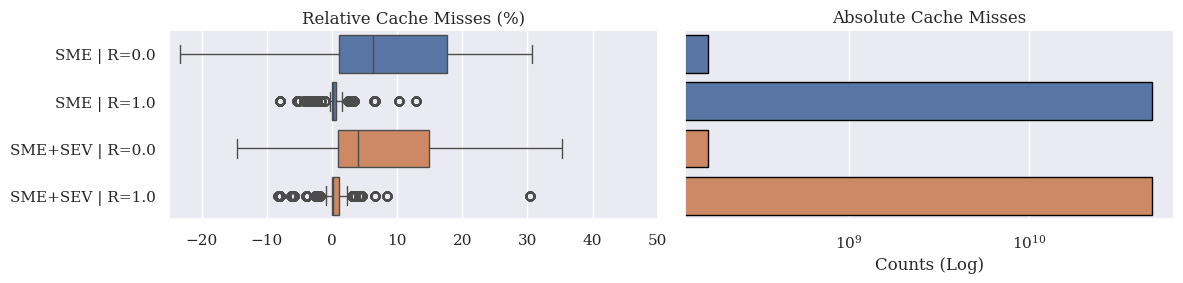

Median Relative Cache Misses (%):
Mode
SME        0.71
SME+SEV    1.03
IQR Relative Cache Misses (%):
Mode
SME        6.77
SME+SEV    4.61
Displayed bar values (Relative Cache Misses %):
Mode_Randomness    Mode  Perf_CacheMisses_pct
    SME | R=0.0     SME                  6.33
    SME | R=1.0     SME                  0.19
SME+SEV | R=0.0 SME+SEV                  4.00
SME+SEV | R=1.0 SME+SEV                  0.22
Displayed bar values (Absolute Cache Misses):
Mode_Randomness    Mode  Perf_CacheMisses_x
    SME | R=0.0     SME        1.658003e+08
    SME | R=1.0     SME        4.755615e+10
SME+SEV | R=0.0 SME+SEV        1.650701e+08
SME+SEV | R=1.0 SME+SEV        4.765920e+10


In [ ]:
cmiss_df = overhead_df.copy()
cmiss_df["Mode_Randomness"] = cmiss_df["Mode"] + " | R=" + cmiss_df["Randomness"].astype(str)

cmiss_df = cmiss_df.merge(
    df[["Mode", "Randomness", "Perf_CacheMisses"]],
    on=["Mode", "Randomness"],
    how="left"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)

# LEFT: relative (%)
sns.boxplot(
    data=cmiss_df,
    x="Perf_CacheMisses_pct",
    y="Mode_Randomness",
    hue="Mode",
    ax=axes[0]
)

axes[0].set_title("Relative Cache Misses (%)")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].set_xlim(-25, 50)

# RIGHT: absolute
sns.barplot(
    data=cmiss_df,
    x="Perf_CacheMisses_x",
    y="Mode_Randomness",
    hue="Mode",
    ax=axes[1],
    errorbar=None, #Focus on magnitude
    edgecolor="black"
)

axes[1].set_xscale("log")
axes[1].set_title("Absolute Cache Misses")
axes[1].set_xlabel("Counts (Log)")
axes[1].set_ylabel("")

axes[0].get_legend().remove()
axes[1].get_legend().remove()

plt.tight_layout()
plt.savefig(
    "images/CacheMiss_Relative_vs_Absolute.pdf",
    bbox_inches="tight",
)

plt.show()

print("Median Relative Cache Misses (%):")
print(overhead_df.groupby("Mode")["Perf_CacheMisses_pct"].median().round(2).to_string())
print("IQR Relative Cache Misses (%):")
iqr = overhead_df.groupby("Mode")["Perf_CacheMisses_pct"].agg(lambda x: x.quantile(0.75) - x.quantile(0.25))
print(iqr.round(2).to_string())
rel_bar_vals = (
    cmiss_df.groupby(["Mode_Randomness", "Mode"], as_index=False)["Perf_CacheMisses_pct"]
    .median()
    .round(2)
    .sort_values(["Mode_Randomness", "Mode"])
)
print("Displayed bar values (Relative Cache Misses %):")
print(rel_bar_vals.to_string(index=False))

abs_bar_vals = (
    cmiss_df.groupby(["Mode_Randomness", "Mode"], as_index=False)["Perf_CacheMisses_x"]
    .mean()
    .round(2)
    .sort_values(["Mode_Randomness", "Mode"])
)
print("Displayed bar values (Absolute Cache Misses):")
print(abs_bar_vals.to_string(index=False))

### dTLB misses

            median
Mode              
SME      -1.226530
SME+SEV  26.696486


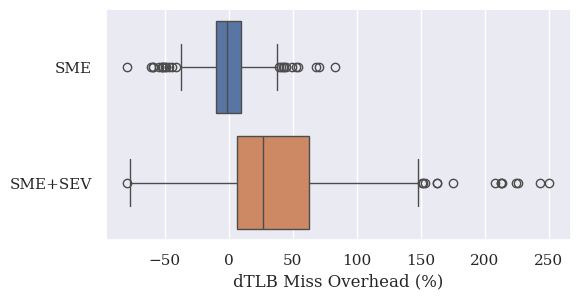

In [32]:
plt.figure(figsize=(6, 3))

sns.boxplot(
    data=overhead_df, 
    x="Perf_dTLBMisses_pct", 
    y="Mode", 
    hue="Mode",
)
plt.xlabel("dTLB Miss Overhead (%)")
plt.ylabel("")
plt.savefig("images/dTLB_Miss_Overhead_Distribution.pdf", bbox_inches='tight')

print(overhead_df.groupby("Mode")["Perf_dTLBMisses_pct"].aggregate(['median']))

> **Sign convention:**  
> * GFLOPS diff < 0 → SEV incurs *more* overhead than SME alone  
> * dTLB diff > 0 → SEV incurs *more* dTLB misses than SME alone


Pearson : -0.21548105913543178
Spearman: -0.21722386019322387


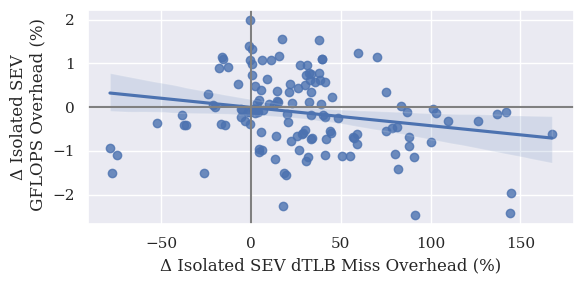

In [33]:
pivot = overhead_df.pivot_table(
    index=["MB", "Cores", "VM_NUMA", "Process_NUMA", "Randomness"],
    columns="Mode",
    values=["SpMV_GFLOPS_pct", "Perf_dTLBMisses_pct"]
)

pivot.columns = ["_".join(col) for col in pivot.columns]

pivot["GFLOPS_diff"] = ( pivot["SpMV_GFLOPS_pct_SME+SEV"] - pivot["SpMV_GFLOPS_pct_SME"])
pivot["dTLB_diff"] = ( pivot["Perf_dTLBMisses_pct_SME+SEV"] - pivot["Perf_dTLBMisses_pct_SME"])

corr_df = pivot[["GFLOPS_diff", "dTLB_diff"]].dropna().copy()
corr_iqr = iqr_filter(corr_df, ["GFLOPS_diff", "dTLB_diff"])

print("Pearson :", corr_iqr["GFLOPS_diff"].corr(corr_iqr["dTLB_diff"], method="pearson"))
print("Spearman:", corr_iqr["GFLOPS_diff"].corr(corr_iqr["dTLB_diff"], method="spearman"))

plt.figure(figsize=(6, 3))
sns.regplot( data=corr_iqr, x="dTLB_diff", y="GFLOPS_diff")
plt.axhline(0, color="gray")
plt.axvline(0, color="gray")

plt.xlabel("Δ Isolated SEV dTLB Miss Overhead (%)")
plt.ylabel("Δ Isolated SEV\n GFLOPS Overhead (%)")
plt.tight_layout()
plt.savefig("images/gflops_dtlb_correlation.pdf", bbox_inches="tight")
plt.show()

### ANOVA: drivers of dTLB miss overhead

In [34]:
dtlb_target = 'Perf_dTLBMisses_pct'

for mode in ('SME', 'SME+SEV'):
    factors = full_anova(overhead_df[overhead_df['Mode'] == mode].copy(), dtlb_target)
    print(f"\n=== {mode}: drivers of {dtlb_target} ===")
    print(factors[['sum_sq', 'df', 'F', 'PR(>F)', 'eta_sq']].to_string(float_format='{:.4f}'.format))
    print(f"Top driver: {factors.index[0]}  (eta²={factors.iloc[0]['eta_sq']:.3f})")



=== SME: drivers of Perf_dTLBMisses_pct ===
                    sum_sq       df      F  PR(>F)  eta_sq
Residual        96689.4015 154.0000    NaN     NaN  0.9704
MB               1940.6519   1.0000 3.0909  0.0807  0.0195
C(Randomness)     440.2710   1.0000 0.7012  0.4037  0.0044
Cores             346.6819   1.0000 0.5522  0.4586  0.0035
Intercept         189.6643   1.0000 0.3021  0.5834  0.0019
C(VM_NUMA)         36.3664   1.0000 0.0579  0.8101  0.0004
C(Process_NUMA)     0.1758   1.0000 0.0003  0.9867  0.0000
Top driver: Residual  (eta²=0.970)

=== SME+SEV: drivers of Perf_dTLBMisses_pct ===
                     sum_sq       df       F  PR(>F)  eta_sq
Residual        521595.7392 154.0000     NaN     NaN  0.6557
Intercept       137088.4979   1.0000 40.4751  0.0000  0.1723
C(VM_NUMA)      118801.5577   1.0000 35.0759  0.0000  0.1494
MB               10663.4898   1.0000  3.1484  0.0780  0.0134
Cores             6326.9652   1.0000  1.8680  0.1737  0.0080
C(Randomness)      866.9498   1.0

## 2.9 I/O time analysis

I/O overhead as a function of matrix size, and sensitivity to randomness.

Mode     MB  
SME      10       3.762282
         70       6.541224
         150      7.040207
         500      7.128418
         3000     8.245188
SME+SEV  10       4.113318
         70       7.937879
         150      8.795880
         500      9.552155
         3000    10.576922
Name: IO_Time_pct, dtype: float64

Average absolute deviation between randomness across configurations: 1.135%


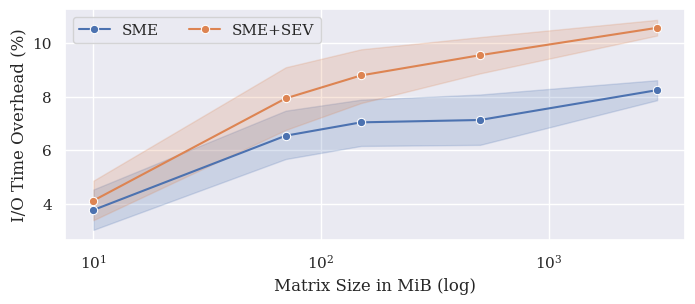

In [35]:
plt.figure(figsize=(8, 3))
sns.lineplot(data=overhead_df, x="MB", y="IO_Time_pct", marker="o", hue="Mode")
plt.xscale("log")
plt.xlabel("Matrix Size in MiB (log)")
plt.ylabel("I/O Time Overhead (%)")
plt.legend(ncol=2)
plt.savefig("images/IO_Time_Overhead_by_MB.pdf", bbox_inches='tight')
print(overhead_df.groupby(["Mode", "MB"])["IO_Time_pct"].mean())
cfg_cols = ["Mode", "MB", "Cores", "Process_NUMA", "VM_NUMA"]

io_rand_cmp = (
	overhead_df
	.pivot_table(
		index=cfg_cols,
		columns="Randomness",
		values="IO_Time_pct",
		aggfunc="mean"
	)
	.dropna(subset=[0.0, 1.0])
	.reset_index()
)

io_rand_cmp["IO_Time_Deviation_pct"] = io_rand_cmp[1.0] - io_rand_cmp[0.0]
io_rand_cmp["Abs_IO_Time_Deviation_pct"] = io_rand_cmp["IO_Time_Deviation_pct"].abs()

print(f"\nAverage absolute deviation between randomness across configurations: {io_rand_cmp['Abs_IO_Time_Deviation_pct'].mean():.3f}%")
diff = io_rand_cmp["IO_Time_Deviation_pct"]

## 2.10 Worst configurations

Characterise the bottom-10 % of configurations by GFLOPS overhead: 
which parameter values are over-represented?

In [36]:
def top_10_percent_per_mode(df, value_col):
    return df[
        df.groupby("Mode")[value_col]
          .transform(lambda x: x.rank(method="first", ascending=True)
                               <= int(len(x) * 0.1))
    ]

cutoffs = overhead_df.groupby("Mode")["SpMV_GFLOPS_pct"].apply(
    lambda x: x.nsmallest(int(len(x) * 0.1)).max()
)

print(cutoffs)

top_configs = top_10_percent_per_mode(overhead_df, "SpMV_GFLOPS_pct")

result_df = (
    top_configs
    .melt(id_vars=["Mode"], value_vars=config_cols,
          var_name="Metric", value_name="Value")
    .groupby(["Mode", "Metric", "Value"])
    .size()
    .reset_index(name="Count")
)

result_df["Representation"] = (
    result_df.groupby(["Mode", "Metric"])["Count"]
    .transform(lambda x: 100 * x / x.sum())
)

result_df = result_df.sort_values(
    ["Mode", "Metric", "Representation"],
    ascending=[True, True, False]
)

n_levels = overhead_df[config_cols].nunique()

result_df["Expected"] = result_df["Metric"].map(lambda m: 1 / n_levels[m])

result_df["Lift"] = (
    result_df["Representation"] / 100
) / result_df["Expected"]

result_df

Mode
SME       -4.723854
SME+SEV   -4.960052
Name: SpMV_GFLOPS_pct, dtype: float64


,Mode,Metric,Value,Count,Representation,Expected,Lift
0,SME,Cores,1.0,10,62.50,0.25,2.5000
1,SME,Cores,24,3,18.75,0.25,0.7500
2,SME,Cores,48,3,18.75,0.25,0.7500
3,SME,L3_fit,0.0,14,87.50,0.50,1.7500
4,SME,L3_fit,1.0,2,12.50,0.50,0.2500
9,SME,MB,3000,6,37.50,0.20,1.8750
8,SME,MB,500,5,31.25,0.20,1.5625
7,SME,MB,150,3,18.75,0.20,0.9375
5,SME,MB,10,1,6.25,0.20,0.3125
6,SME,MB,70,1,6.25,0.20,0.3125
